<a href="https://colab.research.google.com/github/GuilhermeMBertolo/CIC_IDS2017/blob/main/CIC_IDS_2017_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIC-IDS-2017 | XGBoost

In [ ]:
# =====================================================
# 1. Ambiente e configuracao experimental
# =====================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

SEED = 314159
np.random.seed(SEED)

PASTA = '/content/drive/MyDrive/CIC-IDS-2017/'
ARQUIVOS = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

NOMES_CLASSES = [
    'BENIGN', 'DoS', 'DDoS', 'Brute Force',
    'Web Attack', 'Reconnaissance', 'Bot', 'Raros',
]


In [ ]:
# =====================================================
# 2. Carga, limpeza e agrupamento das classes
# =====================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ambiente local detectado. Ajuste PASTA para a pasta dos CSVs.')


def carregar_e_preparar(pasta, arquivos):
    tabelas = []
    for arquivo in arquivos:
        dados = pd.read_csv(os.path.join(pasta, arquivo), low_memory=False)
        dados.columns = dados.columns.str.strip()
        tabelas.append(dados)

    df = pd.concat(tabelas, ignore_index=True)
    df['Label'] = df['Label'].replace({
        'Web Attack Ã¯Â¿Â½ Brute Force': 'Web Attack - Brute Force',
        'Web Attack Ã¯Â¿Â½ Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack Ã¯Â¿Â½ XSS': 'Web Attack - XSS',
        'Web Attack � Brute Force': 'Web Attack - Brute Force',
        'Web Attack � Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack � XSS': 'Web Attack - XSS',
    })

    antes = len(df)
    df = df.dropna()
    colunas_numericas = df.select_dtypes(include=np.number).columns
    df = df.loc[np.isfinite(df[colunas_numericas]).all(axis=1)]
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Linhas removidas na limpeza: {antes - len(df):,}')

    grupos = {
        'BENIGN': 'BENIGN',
        'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
        'DoS Slowhttptest': 'DoS', 'DoS slowloris': 'DoS',
        'DDoS': 'DDoS',
        'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Web Attack - Brute Force': 'Web Attack',
        'Web Attack - Sql Injection': 'Web Attack',
        'Web Attack - XSS': 'Web Attack',
        'PortScan': 'Reconnaissance', 'Bot': 'Bot',
        'Infiltration': 'Raros', 'Heartbleed': 'Raros',
    }
    codigos = {nome: indice for indice, nome in enumerate(NOMES_CLASSES)}

    df['Label_grupo'] = df['Label'].map(grupos)
    df = df.dropna(subset=['Label_grupo']).copy()
    df['Label_final'] = df['Label_grupo'].map(codigos).astype(int)

    X = df.drop(columns=['Label', 'Label_grupo', 'Label_final'])
    y = df['Label_final']
    print(f'Dataset final: {X.shape[0]:,} linhas e {X.shape[1]} atributos')
    display(df['Label_grupo'].value_counts().reindex(NOMES_CLASSES).to_frame('quantidade'))
    return X, y


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =====================================================
# 3. Divisao estratificada: 80% treino, 10% validacao, 10% teste
# =====================================================

X, y = carregar_e_preparar(PASTA, ARQUIVOS)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED, shuffle=True,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED, shuffle=True,
)

resumo_divisao = pd.DataFrame({
    'Conjunto': ['Treino', 'Validacao', 'Teste'],
    'Linhas': [len(X_train), len(X_val), len(X_test)],
    'Percentual': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
})
resumo_divisao['Percentual'] = (resumo_divisao['Percentual'] * 100).round(2)
display(resumo_divisao)


Linhas removidas na limpeza: 309,945
Dataset final: 2,520,798 linhas e 78 atributos


,quantidade
Label_grupo,
BENIGN,2095057
DoS,193745
DDoS,128014
Brute Force,9150
Web Attack,2143
Reconnaissance,90694
Bot,1948
Raros,47


,Conjunto,Linhas,Percentual
0,Treino,2016638,80.0
1,Validacao,252080,10.0
2,Teste,252080,10.0


In [ ]:
# =====================================================
# 4. Selecao de atributos por importancia do XGBoost
# =====================================================

# Mesmo criterio usado nos demais algoritmos comparaveis: 95% da importancia acumulada.
seletor_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(NOMES_CLASSES),
    eval_metric='mlogloss',
    random_state=SEED,
    tree_method='hist',
    n_estimators=200,
    learning_rate=0.10,
    max_depth=6,
    n_jobs=-1,
)
seletor_xgb.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': seletor_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)
importancias['Importancia_acumulada'] = importancias['Importance'].cumsum() / importancias['Importance'].sum()

features_selecionadas = importancias.loc[
    importancias['Importancia_acumulada'] <= 0.95,
    'Feature',
].tolist()

if not features_selecionadas:
    features_selecionadas = [importancias.iloc[0]['Feature']]

print(f'Features selecionadas: {len(features_selecionadas)}')
display(importancias.head(20))


Features selecionadas: 21


,Feature,Importance,Importancia_acumulada
13,Bwd Packet Length Std,0.213418,0.213418
74,Idle Mean,0.134505,0.347923
76,Idle Max,0.116660,0.464584
12,Bwd Packet Length Mean,0.061026,0.525610
30,Fwd PSH Flags,0.054695,0.580304
68,act_data_pkt_fwd,0.053228,0.633532
52,Average Packet Size,0.050233,0.683766
4,Total Length of Fwd Packets,0.044570,0.728336
14,Flow Bytes/s,0.031720,0.760056
35,Bwd Header Length,0.031349,0.791405


In [ ]:
# =====================================================
# 5. Normalizacao ajustada somente no treino
# =====================================================

# XGBoost nao exige normalizacao, mas mantemos o mesmo fluxo dos algoritmos
# comparaveis para padronizar a entrada apos a selecao de atributos.
scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train[features_selecionadas])
X_val_z = scaler.transform(X_val[features_selecionadas])
X_test_z = scaler.transform(X_test[features_selecionadas])


In [ ]:
# =====================================================
# 6. Validacao com early stopping
# =====================================================

pesos_treino = compute_sample_weight(class_weight='balanced', y=y_train)

parametros_xgb_validacao = {
    'objective': 'multi:softprob',
    'num_class': len(NOMES_CLASSES),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'n_estimators': 1_000,
    'learning_rate': 0.10,
    'max_depth': 8,
    'min_child_weight': 1,
    'subsample': 0.80,
    'colsample_bytree': 0.80,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'n_jobs': -1,
    'early_stopping_rounds': 30,
}

modelo_validacao = XGBClassifier(**parametros_xgb_validacao)
modelo_validacao.fit(
    X_train_z,
    y_train,
    sample_weight=pesos_treino,
    eval_set=[(X_train_z, y_train), (X_val_z, y_val)],
    verbose=50,
)

y_val_pred = modelo_validacao.predict(X_val_z)
metricas_validacao = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted', 'F1 macro', 'Balanced accuracy'],
    'Valor': [
        accuracy_score(y_val, y_val_pred),
        precision_score(y_val, y_val_pred, average='weighted', zero_division=0),
        recall_score(y_val, y_val_pred, average='weighted', zero_division=0),
        f1_score(y_val, y_val_pred, average='weighted', zero_division=0),
        f1_score(y_val, y_val_pred, average='macro', zero_division=0),
        balanced_accuracy_score(y_val, y_val_pred),
    ],
})
metricas_validacao['Valor (%)'] = (metricas_validacao['Valor'] * 100).round(2)
display(metricas_validacao[['Metrica', 'Valor (%)']])

melhor_iteracao = getattr(modelo_validacao, 'best_iteration', None)
if melhor_iteracao is None:
    melhor_iteracao = parametros_xgb_validacao['n_estimators'] - 1

melhor_n_estimators = int(melhor_iteracao) + 1
print(f'Melhor numero de arvores pela validacao: {melhor_n_estimators}')


[0]	validation_0-mlogloss:1.72975	validation_1-mlogloss:1.72992
[50]	validation_0-mlogloss:0.08433	validation_1-mlogloss:0.08599
[100]	validation_0-mlogloss:0.05550	validation_1-mlogloss:0.05740
[150]	validation_0-mlogloss:0.04937	validation_1-mlogloss:0.05154
[200]	validation_0-mlogloss:0.04643	validation_1-mlogloss:0.04858
[250]	validation_0-mlogloss:0.04521	validation_1-mlogloss:0.04743
[300]	validation_0-mlogloss:0.04461	validation_1-mlogloss:0.04688
[350]	validation_0-mlogloss:0.04427	validation_1-mlogloss:0.04658
[400]	validation_0-mlogloss:0.04396	validation_1-mlogloss:0.04626
[417]	validation_0-mlogloss:0.04396	validation_1-mlogloss:0.04631


,Metrica,Valor (%)
0,Accuracy,98.61
1,Precision weighted,99.50
2,Recall weighted,98.61
3,F1 weighted,99.00
4,F1 macro,76.55
5,Balanced accuracy,94.10


Melhor numero de arvores pela validacao: 388


In [ ]:
# =====================================================
# 7. Treino final e avaliacao no teste isolado
# =====================================================

# O modelo final recebe treino + validacao apos a definicao do numero de arvores.
X_modelo = np.vstack([X_train_z, X_val_z])
y_modelo = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])
pesos_modelo = compute_sample_weight(class_weight='balanced', y=y_modelo)

parametros_xgb_final = {
    'objective': 'multi:softprob',
    'num_class': len(NOMES_CLASSES),
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'n_estimators': melhor_n_estimators,
    'learning_rate': 0.10,
    'max_depth': 8,
    'min_child_weight': 1,
    'subsample': 0.80,
    'colsample_bytree': 0.80,
    'reg_lambda': 1.0,
    'random_state': SEED,
    'n_jobs': -1,
}

xgb_final = XGBClassifier(**parametros_xgb_final)
xgb_final.fit(X_modelo, y_modelo, sample_weight=pesos_modelo, verbose=False)
y_pred = xgb_final.predict(X_test_z)

metricas = pd.DataFrame({
    'Metrica': ['Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted', 'F1 macro', 'Balanced accuracy'],
    'Valor': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        balanced_accuracy_score(y_test, y_pred),
    ],
})
metricas['Valor (%)'] = (metricas['Valor'] * 100).round(2)
display(metricas[['Metrica', 'Valor (%)']])

print(classification_report(
    y_test, y_pred, labels=range(len(NOMES_CLASSES)),
    target_names=NOMES_CLASSES, digits=4, zero_division=0,
))


,Metrica,Valor (%)
0,Accuracy,98.76
1,Precision weighted,99.55
2,Recall weighted,98.76
3,F1 weighted,99.10
4,F1 macro,73.80
5,Balanced accuracy,93.22


                precision    recall  f1-score   support

        BENIGN     0.9996    0.9857    0.9926    209506
           DoS     0.9742    0.9948    0.9844     19374
          DDoS     0.9977    0.9994    0.9986     12802
   Brute Force     0.9103    0.9978    0.9520       915
    Web Attack     0.2443    0.9907    0.3919       215
Reconnaissance     0.9897    0.9991    0.9944      9070
           Bot     0.1050    0.9897    0.1898       194
         Raros     0.3333    0.5000    0.4000         4

      accuracy                         0.9876    252080
     macro avg     0.6943    0.9322    0.7380    252080
  weighted avg     0.9955    0.9876    0.9910    252080



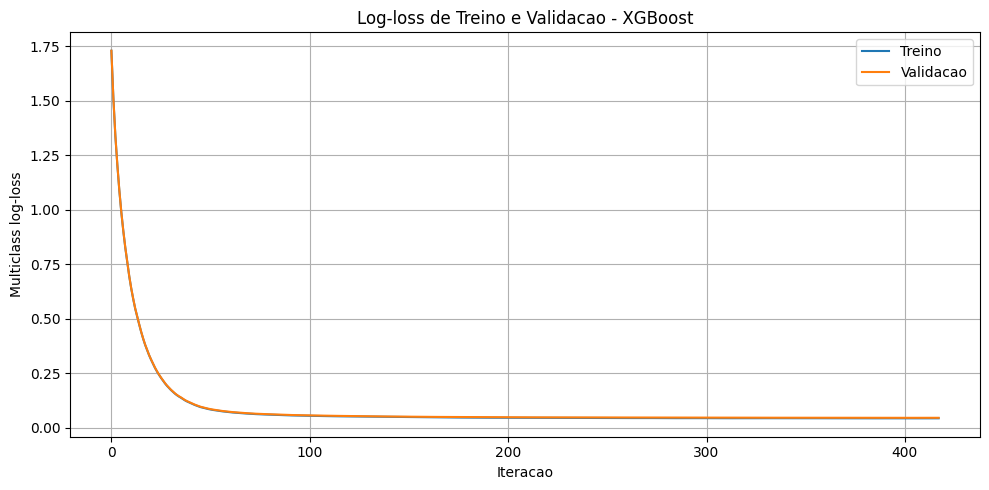

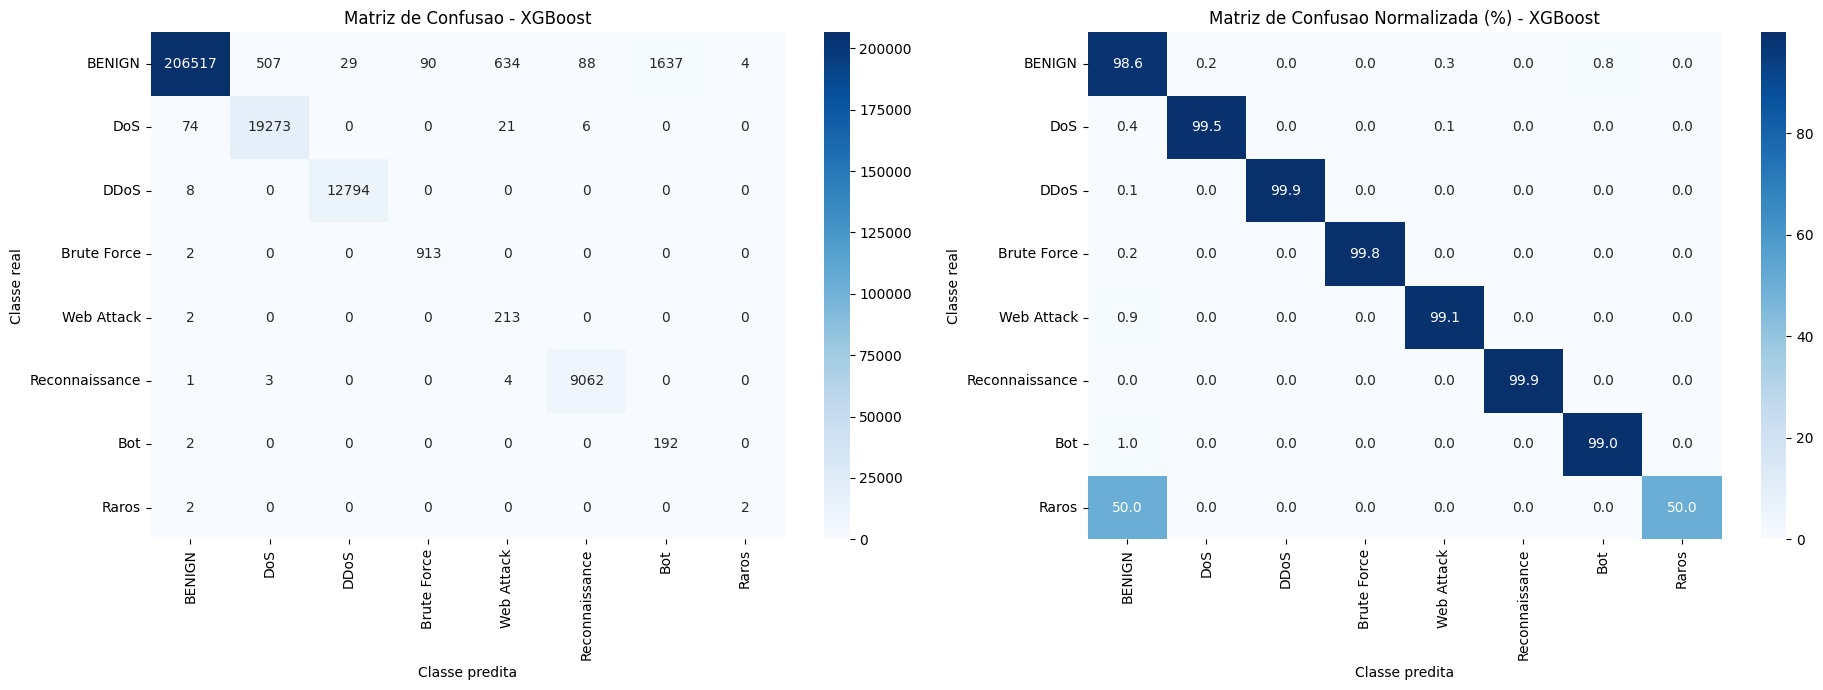

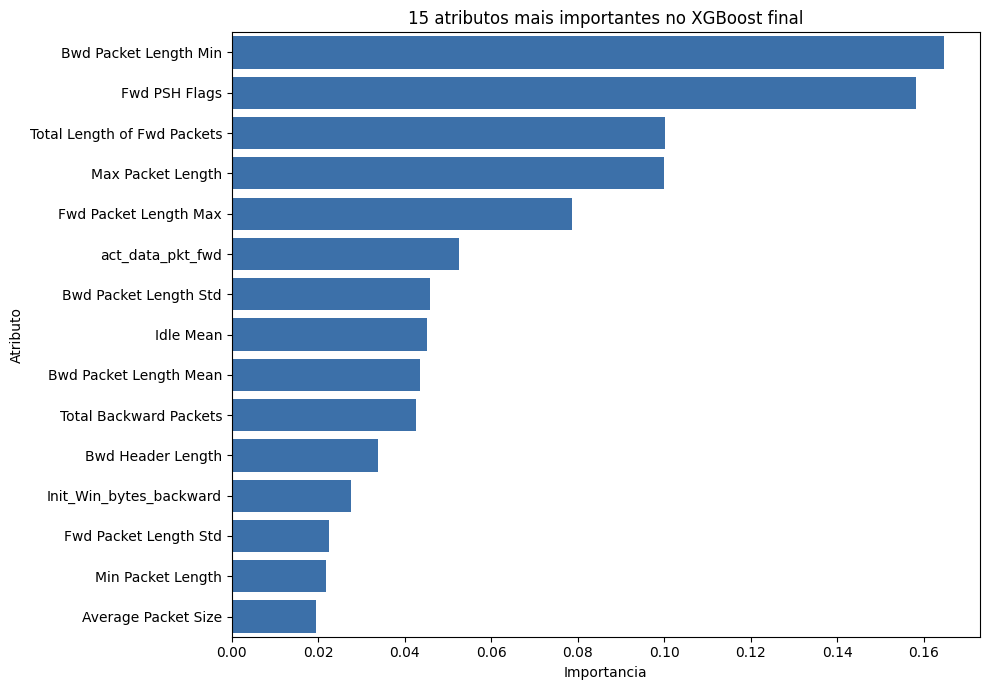

,Feature,Importance
14,Bwd Packet Length Min,0.164809
4,Fwd PSH Flags,0.158220
7,Total Length of Fwd Packets,0.100111
11,Max Packet Length,0.100029
10,Fwd Packet Length Max,0.078715
5,act_data_pkt_fwd,0.052622
0,Bwd Packet Length Std,0.045909
1,Idle Mean,0.045161
3,Bwd Packet Length Mean,0.043493
15,Total Backward Packets,0.042676


In [ ]:
# =====================================================
# 8. Analise visual e interpretacao do modelo
# =====================================================

resultados = modelo_validacao.evals_result()
loss_treino = resultados['validation_0']['mlogloss']
loss_validacao = resultados['validation_1']['mlogloss']

plt.figure(figsize=(10, 5))
plt.plot(loss_treino, label='Treino')
plt.plot(loss_validacao, label='Validacao')
plt.xlabel('Iteracao')
plt.ylabel('Multiclass log-loss')
plt.title('Log-loss de Treino e Validacao - XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred, labels=range(len(NOMES_CLASSES)))
cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(pd.DataFrame(cm, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set(title='Matriz de Confusao - XGBoost', xlabel='Classe predita', ylabel='Classe real')

sns.heatmap(pd.DataFrame(cm_percent, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set(title='Matriz de Confusao Normalizada (%) - XGBoost', xlabel='Classe predita', ylabel='Classe real')
plt.tight_layout()
plt.show()

importancias_finais = pd.DataFrame({
    'Feature': features_selecionadas,
    'Importance': xgb_final.feature_importances_,
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importancias_finais.head(15), x='Importance', y='Feature', color='#2a6fbb')
plt.title('15 atributos mais importantes no XGBoost final')
plt.xlabel('Importancia')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

display(importancias_finais.head(20))


In [ ]:
# =====================================================
# 9. Quantidade de acertos e desvio padrao
# =====================================================

# Quantidade absoluta de acertos/erros na avaliacao principal da etapa 7.
y_test_array = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test)

quantidade_acertos = int((y_test_array == y_pred).sum())
quantidade_erros = int((y_test_array != y_pred).sum())
total_avaliado = len(y_test_array)

resumo_acertos = pd.DataFrame({
    'Indicador': ['Acertos', 'Erros', 'Total avaliado', 'Taxa de acerto (%)'],
    'Valor': [
        quantidade_acertos,
        quantidade_erros,
        total_avaliado,
        round(quantidade_acertos / total_avaliado * 100, 2),
    ],
})
display(resumo_acertos)

# Estimativa de media e desvio padrao por repeticoes no teste isolado.
# O modelo nao e retreinado; apenas avaliamos amostras estratificadas diferentes
# do teste para manter a execucao controlada.
N_REPETICOES_DESVIO = 5
MAX_TESTE_DESVIO_XGB = 10_000


def amostra_estratificada_array(X_array, y_array, max_linhas, seed):
    y_array = np.asarray(y_array)
    if max_linhas is None or len(y_array) <= max_linhas:
        return X_array, y_array

    indices = np.arange(len(y_array))
    indices_amostra, _ = train_test_split(
        indices,
        train_size=max_linhas,
        stratify=y_array,
        random_state=seed,
        shuffle=True,
    )
    return X_array[indices_amostra], y_array[indices_amostra]


resultados_repetidos = []

for repeticao in range(N_REPETICOES_DESVIO):
    X_rep, y_rep = amostra_estratificada_array(
        X_test_z,
        y_test_array,
        MAX_TESTE_DESVIO_XGB,
        SEED + 100 + repeticao,
    )
    pred_rep = xgb_final.predict(X_rep)
    resultados_repetidos.append({
        'Repeticao': repeticao + 1,
        'Total avaliado': len(y_rep),
        'Acertos': int((y_rep == pred_rep).sum()),
        'Erros': int((y_rep != pred_rep).sum()),
        'Accuracy': accuracy_score(y_rep, pred_rep),
        'Precision weighted': precision_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'Recall weighted': recall_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 weighted': f1_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 macro': f1_score(y_rep, pred_rep, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_rep, pred_rep),
    })

resultados_repetidos = pd.DataFrame(resultados_repetidos)
display(resultados_repetidos)

resumo_desvio = resultados_repetidos.drop(columns=['Repeticao']).agg(['mean', 'std']).T
resumo_desvio.columns = ['Media', 'Desvio padrao']

for coluna in ['Media', 'Desvio padrao']:
    resumo_desvio[coluna] = resumo_desvio[coluna].round(4)

display(resumo_desvio)


,Indicador,Valor
0,Acertos,248966.00
1,Erros,3114.00
2,Total avaliado,252080.00
3,Taxa de acerto (%),98.76


,Repeticao,Total avaliado,Acertos,Erros,Accuracy,Precision weighted,Recall weighted,F1 weighted,F1 macro,Balanced accuracy
0,1,10000,9861,139,0.9861,0.995053,0.9861,0.990027,0.784517,0.996388
1,2,10000,9891,109,0.9891,0.995067,0.9891,0.991610,0.798673,0.996514
2,3,10000,9896,104,0.9896,0.996097,0.9896,0.992362,0.796700,0.998044
3,4,10000,9868,132,0.9868,0.995502,0.9868,0.990591,0.782988,0.996888
4,5,10000,9891,109,0.9891,0.996116,0.9891,0.992097,0.788325,0.997284


,Media,Desvio padrao
Total avaliado,10000.0000,0.0000
Acertos,9881.4000,15.7575
Erros,118.6000,15.7575
Accuracy,0.9881,0.0016
Precision weighted,0.9956,0.0005
Recall weighted,0.9881,0.0016
F1 weighted,0.9913,0.0010
F1 macro,0.7902,0.0071
Balanced accuracy,0.9970,0.0007
